<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Prac_09_Comparing_ML_Algorithms%2C_Automating_Workflows%2C_and_Enhancing_ML_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Comparing ML Algorithms, Automating Workflows, and Enhancing ML Performance


We have learned about **four linear machine
learning algorithms**: Linear Regression, Ridge Regression, LASSO Linear Regression and Elastic
Net Regression.

You also learned about **three nonlinear algorithms**:
k-Nearest Neighbors,
Classification and Regression Trees and Support Vector Machines.

Now we will discover
how **to design simple experiments to directly compare machine learning algorithms to each other
on your dataset**.

It is important to compare the performance of multiple different machine learning algorithms
consistently. In this chapter you will discover **how you can create a test harness to compare
multiple different machine learning algorithms in Python with scikit-learn**.

You can use **this
test harness as a template on your own machine learning problems and add more and different
algorithms to compare**. After completing this lesson you will know:
1. How to formulate an experiment to directly compare machine learning algorithms.
2. A reusable template for evaluating the performance of multiple algorithms on one dataset.
3. How to report and visualize the results when comparing algorithm performance.

### Choose The Best Machine Learning Model

When you work on a machine learning project, you often end up with **multiple good models
to choose from**.

Each model will have **different performance characteristics**. Using resampling
methods like **cross validation, you can get an estimate for how accurate each model may be on
unseen data**.

You need to be able to use **these estimates to choose one or two best models** from
the suite of models that you have created.

When you have a new dataset, it is a good idea to visualize the data using different techniques in order to look at the data from different perspectives. The same idea applies to model selection.
**You should use a number of different ways of looking at the estimated accuracy of your machine
learning algorithms in order to choose the one or two algorithm to finalize**.

A way to do this is
to use **visualization methods to show the average accuracy, variance and other properties of the
distribution of model accuracies**.

In the next section you will discover exactly how you can do
that in Python with scikit-learn.

### Compare Machine Learning Algorithms Consistently

The key to a **fair comparison of machine learning algorithms is ensuring that each algorithm is
evaluated in the same way on the same data**.

You can achieve this by forcing each algorithm to be evaluated on a consistent test harness. In the **example below six different classification algorithms are compared on a single dataset**:
- Logistic Regression.
- Linear Discriminant Analysis.
- k-Nearest Neighbors.
- Classification and Regression Trees.
- Naive Bayes.
- Support Vector Machines.

The dataset is the corrosion ship  problem.
- The problem has **two classes and eight numeric input variables of varying scales**.
- The **10-fold cross validation procedure** is used to evaluate each algorithm,
- **importantly configured with the same random seed** to ensure that the same splits to the training data are performed and that each algorithm is evaluated in precisely the same way.
- Each algorithm is given a **short name**, useful for summarizing results afterward.

---
**Load the file from a url to `content/data_sample`**

---

First of all we will load the file from a url and then save it in `content/data_sample`.

In [ ]:
!wget -O /content/sample_data/Corrosion_Detection_Ships.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Corrosion_Detection_Ships.csv

--2025-03-30 07:14:39--  https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Corrosion_Detection_Ships.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘/content/sample_data/Corrosion_Detection_Ships.csv’

/content/sample_dat 100%[===================>]  22.73K  --.-KB/s    in 0.001s  

2025-03-30 07:14:39 (32.5 MB/s) - ‘/content/sample_data/Corrosion_Detection_Ships.csv’ saved [23278/23278]



---
**Compare Algorithms**

---

LR: 0.772163 (0.049684)
LDA: 0.766969 (0.047966)
KNN: 0.710988 (0.050792)
CART: 0.698018 (0.048662)
NB: 0.759142 (0.038960)
SVM: 0.760458 (0.034712)


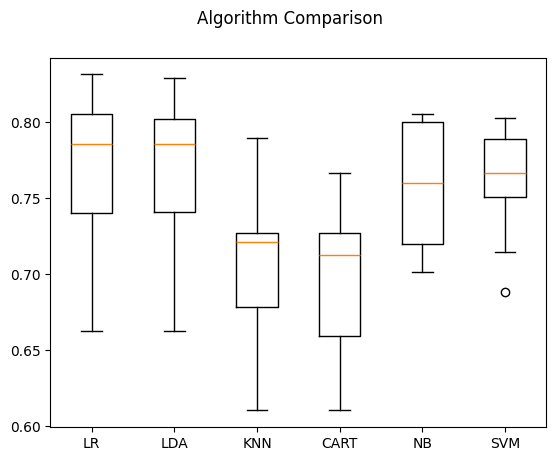

In [ ]:
from pandas import read_csv
from matplotlib import pyplot
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Cargar dataset
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:, 0:8]
Y = array[:, 8]

# Preparar modelos
models = []
models.append(('LR', LogisticRegression(max_iter=1000)))  # Aumentamos max_iter
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Evaluar modelos
results = []
names = []
scoring = 'accuracy'

for name, model in models:
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Comparación de algoritmos
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()


Running the example provides a **list of each algorithm short name, the mean accuracy and
the standard deviation accuracy**.

The example also provides **a box and whisker plot showing the spread of the accuracy scores
across each cross validation fold for each algorithm**.

From these results, it would suggest that both **logistic regression and linear discriminant
analysis** are perhaps worthy of further study on this problem.

**But what if you need to prepare your data as part of the comparison process**. There are standard **workflows** in a machine learning project that can be automated. In Python
scikit-learn, **Pipelines** help to clearly define and automate these workflows. We are going to study:
1. How to use **pipelines to minimize data leakage**.
2. How to construct **a data preparation and modeling pipeline**.
3. How to construct **a feature extraction and modeling pipeline**.


## Automating Machine Learning Workflows

There are **standard workflows in applied machine learning**.

- Standard because they **overcome
common problems** like data leakage in your test harness.
- Python **scikit-learn provides a Pipeline
utility to help automate machine learning workflows**.
- Pipelines work by allowing for **a linear
sequence of data transforms to be chained together** culminating in a modeling process that can be evaluated.

**The goal is to ensure that all of the steps in the pipeline are constrained to the data available
for the evaluation**, such as the training dataset or each fold of the cross validation procedure.

- You can learn more about Pipelines in scikit-learn by reading the [Pipeline section](http://scikit-learn.org/stable/modules/classes.html#m) of the user
guide.
- You can also review the **API documentation** for the Pipeline and FeatureUnion classes
and the [`pipeline` module](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.pipeline).

## Data Preparation and Modeling Pipeline
**An easy trap to fall into in applied machine learning is leaking data from your training dataset
to your test dataset**.

**To avoid this trap you need a robust test harness with strong separation of training and testing**. This includes **data preparation**.


**Data preparation is one easy way to leak
knowledge of the whole training dataset to the algorithm**.
- For example, preparing your data
using **normalization or standardization on the entire _training dataset_ before learning would not
be a valid test** because the **training dataset would have been influenced by the _scale_** of the data in the test set.

- Pipelines help you prevent data leakage in your test harness by ensuring that data preparation
like **standardization is constrained to each fold of your cross validation procedure**.

The example below demonstrates this important data preparation and model evaluation workflow on the
Corrosion ships dataset.

The pipeline is defined with two steps:
  1. Standardize the data.
  2. Learn a Linear Discriminant Analysis model.

The pipeline is then evaluated using 10-fold cross validation.

---
**Create a pipeline that standardizes the data then creates a model**

---

In [ ]:
# Create a pipeline that standardizes the data then creates a model
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
# create pipeline
estimators = []
estimators.append(('standardize', StandardScaler()))
estimators.append(('lda', LinearDiscriminantAnalysis()))
model = Pipeline(estimators)
# evaluate pipeline
kfold = KFold(n_splits=10, random_state=7,shuffle=True)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7669685577580315


**Notice:**

1. How we create a Python list of steps that are provided to the Pipeline for process
the data.
2. Also notice how the Pipeline itself is treated like an estimator and is evaluated in its
entirety by the k-fold cross validation procedure.

Running the example provides a summary of
accuracy of the setup on the dataset.

## Feature Extraction and Modeling Pipeline

**Feature extraction is another procedure that is susceptible to data leakage**.

Like data preparation,
feature extraction procedures **must be restricted to the data in your training dataset**. The
pipeline provides a handy tool called the `FeatureUnion` which **allows the results of multiple
feature selection and extraction procedures to be combined into a larger dataset on which a
model can be trained**.

Importantly, all the feature extraction and the feature union occurs
within each fold of the cross validation procedure. The example below demonstrates the pipeline
defined with four steps:

1. Feature Extraction with Principal Component Analysis (3 features).
2. Feature Extraction with Statistical Selection (6 features).
3. Feature Union.
4. Learn a Logistic Regression Model.

The pipeline is then evaluated using 10-fold cross validation.

---
**Create a pipeline that extracts features from the data then creates a model**

---

In [ ]:
# Create a pipeline that extracts features from the data then creates a model
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
# create feature union
features = []
features.append(('pca', PCA(n_components=3)))
features.append(('select_best', SelectKBest(k=6)))
feature_union = FeatureUnion(features)
# create pipeline
estimators = []
estimators.append(('feature_union', feature_union))
estimators.append(('logistic', LogisticRegression(max_iter=500)))
model = Pipeline(estimators)
# evaluate pipeline
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7721633629528366


**Notice:**
1. how the `Feature Union` is it’s own Pipeline that in turn is a single step in the final
Pipeline used to feed Logistic Regression.
2. This might get you thinking about how you can start
embedding pipelines within pipelines.

Running the example provides a summary of accuracy of
the setup on the dataset.

## Combine Models Into Ensemble Predictions

We have learned how to use Pipelines in two important
use cases:
- Data preparation and modeling constrained to each fold of the cross validation procedure.
- Feature extraction and feature union constrained to each fold of the cross validation
procedure.

Now, we are going to learn **how ensembles can give us a boost in accuracy on our dataset**.

We will discover
how you can create some of the most powerful types of ensembles in Python using scikit-learn.
This lesson will step you through **Boosting, Bagging and Majority Voting and show you how you
can continue to ratchet up the accuracy of the models on your own datasets**.

After completing
this lesson you will know:
1. How to use **bagging ensemble methods** such as bagged decision trees, random forest and
extra trees.
2. How to use **boosting ensemble methods** such as **AdaBoost and stochastic gradient boosting**.
3. How to use **voting ensemble methods** to combine the predictions from multiple algorithms.

The three most popular methods for combining the predictions from different models are:
- **Bagging**. Building multiple models (typically of the _same type_) from **different subsamples**
of the training dataset.
- **Boosting**. Building multiple models (typically of the _same type_) each of which learns to
**fix the prediction errors of a prior model** in the sequence of models.
- **Voting**. Building multiple models (typically of _differing types_) and simple statistics (like
calculating the mean) are used to **combine predictions**.

This assumes you are generally familiar with machine learning algorithms and ensemble
methods and **will not go into the details of how the algorithms work or their parameters**.

The Corrosion ship dataset is used to demonstrate each algorithm. Each
ensemble algorithm is demonstrated using 10-fold cross validation and the classification accuracy
performance metric.

## Bagging Algorithms
Bootstrap Aggregation (or Bagging) involves **taking multiple samples from your training dataset
(with replacement)** and training a model for each sample. The final **output prediction is averaged
across the predictions of all of the sub-models**.

The three bagging models covered in this section
are as follows:
- Bagged Decision Trees.
- Random Forest.
- Extra Trees.

### Bagged Decision Trees

Bagging performs best with algorithms that have **high variance**. A popular example are
**decision trees**, often constructed without pruning.

In the example below is an example
of using the `BaggingClassifier` with the Classification and Regression Trees algorithm
([`DecisionTreeClassifier`](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) ).

A total of 100 trees are created.

---
**Bagged Decision Trees for Classification**

---

In [ ]:
# Bagged Decision Trees for Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
cart = DecisionTreeClassifier()
num_trees = 100
model = BaggingClassifier(estimator=cart, n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7578263841421736


Running the example, we get a robust estimate of model accuracy.

### Random Forest

**Random Forests is an extension of bagged decision trees**.

**Samples of the training dataset are
taken with replacement, but the trees are constructed in a way that reduces the correlation
between individual classifiers**.

Specifically, rather than greedily choosing the best split point in
the construction of each tree, **only a random subset of features are considered for each split**.

You can construct a Random Forest model for classification using the [`RandomForestClassifier`
class](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) .

The example below demonstrates using Random Forest for classification with 100 trees
and split points chosen from a random selection of 3 features.

---
**Random Forest Classification**

---

In [ ]:
# Random Forest Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
num_trees = 100
max_features = 3
kfold = KFold(n_splits=10, random_state=7,shuffle=True)
model = RandomForestClassifier(n_estimators=num_trees, max_features=max_features)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7721804511278195


Running the example provides a mean estimate of classification accuracy.

### Extra Trees

Extra Trees are another modification of bagging where random trees are constructed from
samples of the training dataset. You can construct an Extra Trees model for classification using
the [`ExtraTreesClassifier class`](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html) . The example below provides a demonstration of extra trees
with the number of trees set to 100 and splits chosen from 7 random features.

---
**Extra Trees Classification**

---

In [ ]:
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import ExtraTreesClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
num_trees = 100
max_features = 7
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
model = ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7708817498291183


Running the example provides a mean estimate of classification accuracy.

## Boosting Algorithms
Boosting ensemble algorithms creates a sequence of models that attempt to correct the mistakes
of the models before them in the sequence. Once created, the models make predictions which
may be weighted by their demonstrated accuracy and the results are combined to create a final
output prediction. The two most common boosting ensemble machine learning algorithms are:
- AdaBoost.
- Stochastic Gradient Boosting.

### AdaBoost
AdaBoost was perhaps the first successful boosting ensemble algorithm. It generally works
by weighting instances in the dataset by how easy or difficult they are to classify, allowing
the algorithm to pay or less attention to them in the construction of subsequent models. You
can construct an AdaBoost model for classification using the [`AdaBoostClassifier` class](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) . The
example below demonstrates the construction of 30 decision trees in sequence using the AdaBoost
algorithm.

---
**AdaBoost Classification**

---

In [ ]:
# AdaBoost Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import AdaBoostClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
num_trees = 30
seed=7
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = AdaBoostClassifier(n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7552460697197538


Running the example provides a mean estimate of classification accuracy.

### Stochastic Gradient Boosting
Stochastic Gradient Boosting (also called Gradient Boosting Machines) are **one of the most
sophisticated ensemble techniques**.

It is also a technique that is proving to be **perhaps one of
the best techniques available for improving performance via ensembles**.
You can construct a
Gradient Boosting model for classification using the [`GradientBoostingClassifier` class](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) .

The
example below demonstrates Stochastic Gradient Boosting for classification with 100 trees.

---
**Stochastic Gradient Boosting Classification**

---

In [ ]:
# Stochastic Gradient Boosting Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
seed = 7
num_trees = 100
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
model = GradientBoostingClassifier(n_estimators=num_trees, random_state=seed)
results = cross_val_score(model, X, Y, cv=kfold)
print(results.mean())

0.7578947368421053


Running the example provides a mean estimate of classification accuracy.

## Voting Ensemble

Voting is one of the **simplest ways of combining the predictions from multiple machine learning
algorithms**.

It works by first **creating two or more standalone models from your training dataset**.

A **Voting Classifier can then be used to wrap your models and average the predictions of the
sub-models when asked to make predictions for new data**. The predictions of the sub-models **can
be weighted**, but specifying the weights for classifiers manually or even heuristically **is difficult**.

More advanced methods **can learn how to best weight the predictions from sub-models**, but this
is called **stacking (stacked aggregation) and is currently not provided in scikit-learn**.

You can create a voting ensemble model for classification using the [`VotingClassifier`
class](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html) .

The code below provides an example of combining the predictions of logistic regression,
classification and regression trees and support vector machines together for a classification
problem.

---
**Voting Ensemble for Classification**

---

In [ ]:
# Voting Ensemble for Classification
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
# load data
filename = '/content/sample_data/Corrosion_Detection_Ships.csv'
names = ['Years_since_last_inspection',
          'Water_salinity',
          'Water_pressure',
          'Coating_thickness',
          'Anti_corrosion_concentration',
          'Hull_material_density',
          'Inspection_history',
          'Ship_age',
          'Hull_Condition']
data = read_csv(filename, names=names)
array = data.values
X = array[:,0:8]
Y = array[:,8]
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
# create the sub models
estimators = []
model1 = LogisticRegression(max_iter=500)
estimators.append(('logistic', model1))
model2 = DecisionTreeClassifier()
estimators.append(('cart', model2))
model3 = SVC()
estimators.append(('svm', model3))
# create the ensemble model
ensemble = VotingClassifier(estimators)
results = cross_val_score(ensemble, X, Y, cv=kfold)
print(results.mean())

0.7708646616541355


Running the example provides a mean estimate of classification accuracy.

---
## Homework: Advanced ML Workflows for Naval Engineering Applications

---


In [ ]:
# ====================================================================
# NAVAL ENGINEERING: ADVANCED ML WORKFLOWS HOMEWORK
# Pipelines, Ensembles, and Model Comparison
# ====================================================================

# ====================================================================
# STUDENT INFORMATION
# ====================================================================
# Name: [Your Name]
# Student ID: [Your ID]
# Date: [Date]
# Assignment: Advanced ML Workflows for Naval Engineering

"""
HOMEWORK OVERVIEW:
This assignment focuses on building robust, production-ready machine learning
workflows for naval engineering applications. You will learn to:

1. Prevent data leakage using pipelines
2. Compare multiple algorithms systematically
3. Build ensemble models for improved predictions
4. Automate feature engineering workflows
5. Create deployment-ready model selection frameworks

Dataset: Corrosion Detection Ships Dataset
Application: Predicting hull corrosion for maintenance planning
"""

# ====================================================================
# REQUIRED IMPORTS
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.model_selection import (
    KFold, cross_val_score, GridSearchCV,
    learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, RFE, chi2, f_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    ExtraTreesClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, VotingClassifier
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
np.random.seed(42)

print("="*70)
print("NAVAL ENGINEERING: ADVANCED ML WORKFLOWS")
print("="*70)

# ====================================================================
# PART 0: DATA LOADING AND EXPLORATION
# ====================================================================

print("\n" + "="*70)
print("PART 0: DATA LOADING AND EXPLORATION")
print("="*70)

# TODO: Download the Corrosion Detection Ships dataset
# TODO: Load the data and display basic information
# TODO: Check for missing values and outliers
# TODO: Visualize class distribution
# TODO: Create correlation heatmap
# TODO: Analyze feature distributions

# ====================================================================
# PART 1: SYSTEMATIC ALGORITHM COMPARISON
# ====================================================================

print("\n" + "="*70)
print("PART 1: SYSTEMATIC ALGORITHM COMPARISON")
print("="*70)

"""
OBJECTIVE: Compare multiple algorithms using consistent evaluation
methodology to identify the most promising models for corrosion detection.

REQUIREMENTS:
1. Implement ALL of the following algorithms:
   - Logistic Regression
   - Linear Discriminant Analysis
   - K-Nearest Neighbors
   - Decision Trees (CART)
   - Naive Bayes
   - Support Vector Machines

2. Use IDENTICAL evaluation conditions:
   - Same train/test splits
   - Same random seed
   - Same scoring metrics
   - Same cross-validation strategy

3. Record for EACH algorithm:
   - Mean accuracy
   - Standard deviation
   - Training time
   - Prediction time
   - Memory usage (bonus)

4. Create visualizations:
   - Box plots comparing accuracy distributions
   - Bar chart of mean accuracies
   - Training time comparison
   - Prediction time comparison
"""

# TODO: Create a dictionary to store all models
models = {}
# models['LR'] = LogisticRegression(max_iter=1000)
# models['LDA'] = LinearDiscriminantAnalysis()
# ... add remaining models

# TODO: Set up consistent cross-validation
kfold = None  # Use KFold with 10 splits, random_state=7, shuffle=True

# TODO: Create results storage
results = []
names = []
timing_results = {}

# TODO: Evaluate each model
for name, model in models.items():
    # TODO: Time the cross-validation
    # TODO: Store cv_results, timing, and model name
    pass

# TODO: Create comparison visualizations
# Box plot of accuracy distributions
# Bar chart of mean accuracies with error bars
# Timing comparison charts

# TODO: Generate summary table
def create_comparison_table(results, names, timing_results):
    """
    Create a comprehensive comparison table.

    Returns DataFrame with:
    - Algorithm name
    - Mean accuracy
    - Std deviation
    - Min/Max accuracy
    - Training time
    - Prediction time
    """
    # TODO: Implement
    pass

# ====================================================================
# PART 2: DATA PREPARATION PIPELINES
# ====================================================================

print("\n" + "="*70)
print("PART 2: DATA PREPARATION PIPELINES")
print("="*70)

"""
OBJECTIVE: Demonstrate proper use of pipelines to prevent data leakage
and ensure robust model evaluation.

CRITICAL CONCEPT: Data preprocessing (scaling, normalization) must be
fit ONLY on training data, then applied to test data. Pipelines ensure
this happens automatically within cross-validation.

TASKS:
1. Create pipelines with different preprocessing strategies
2. Compare preprocessing methods (StandardScaler, MinMaxScaler, RobustScaler)
3. Show the DANGER of preprocessing before cross-validation
4. Demonstrate the CORRECT pipeline approach
"""

# TODO: Implement INCORRECT approach (data leakage example)
def demonstrate_data_leakage(X, y):
    """
    Show what happens when you preprocess before cross-validation.
    This is WRONG but educational!
    """
    # TODO: Scale entire dataset first
    # TODO: Then do cross-validation
    # TODO: Show inflated accuracy scores
    pass

# TODO: Implement CORRECT approach with pipelines
preprocessing_methods = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

# TODO: For each preprocessing method:
#   1. Create pipeline with preprocessing + LDA
#   2. Evaluate with cross-validation
#   3. Compare results

# TODO: Create visualization showing:
# - Accuracy with different preprocessing methods
# - Comparison of leakage vs. correct approach

# ====================================================================
# PART 3: FEATURE ENGINEERING PIPELINES
# ====================================================================

print("\n" + "="*70)
print("PART 3: FEATURE ENGINEERING PIPELINES")
print("="*70)

"""
OBJECTIVE: Build automated feature engineering pipelines that combine
multiple feature transformation strategies.

FEATURE ENGINEERING STRATEGIES:
1. Statistical feature selection (SelectKBest)
2. Dimensionality reduction (PCA)
3. Recursive feature elimination (RFE)
4. Combined approaches using FeatureUnion

NAVAL ENGINEERING CONTEXT:
Different feature engineering approaches may capture different aspects
of corrosion risk:
- PCA: Overall corrosion patterns
- SelectKBest: Individual high-risk factors
- Combined: Comprehensive risk assessment
"""

# TODO: Create feature selection pipeline
def create_feature_pipeline(method='pca', n_features=3):
    """
    Create a pipeline with specified feature engineering.

    Args:
        method: 'pca', 'selectkbest', 'rfe', or 'union'
        n_features: number of features to select/extract
    """
    # TODO: Implement different methods
    pass

# TODO: Experiment with different feature engineering strategies:

# Strategy 1: PCA only
# TODO: Create pipeline with PCA(n_components=[2,3,4,5])
# TODO: Evaluate with LDA classifier
# TODO: Plot accuracy vs. number of components

# Strategy 2: SelectKBest only
# TODO: Create pipeline with SelectKBest(k=[3,4,5,6,7,8])
# TODO: Evaluate with Logistic Regression
# TODO: Plot accuracy vs. number of features

# Strategy 3: RFE (Recursive Feature Elimination)
# TODO: Create pipeline with RFE
# TODO: Evaluate with SVC
# TODO: Identify most important features

# Strategy 4: FeatureUnion (Combined approach)
# TODO: Create pipeline combining PCA + SelectKBest
# TODO: Evaluate with multiple classifiers
# TODO: Compare with individual methods

# TODO: Visualize feature importance/selection results

# ====================================================================
# PART 4: COMPLETE PREPROCESSING + FEATURE + MODEL PIPELINE
# ====================================================================

print("\n" + "="*70)
print("PART 4: COMPLETE PREPROCESSING + FEATURE + MODEL PIPELINE")
print("="*70)

"""
OBJECTIVE: Build end-to-end pipelines that combine:
1. Data preprocessing (scaling)
2. Feature engineering (selection/extraction)
3. Model training

This represents a PRODUCTION-READY workflow.
"""

# TODO: Create comprehensive pipeline
def create_complete_pipeline(
    scaler='standard',
    feature_method='pca',
    n_features=5,
    classifier='lda'
):
    """
    Create complete preprocessing + feature + model pipeline.
    """
    # TODO: Build pipeline with multiple steps
    # Step 1: Scaling
    # Step 2: Feature engineering
    # Step 3: Classification
    pass

# TODO: Test different pipeline configurations
pipeline_configs = [
    {'scaler': 'standard', 'feature': 'pca', 'n': 3, 'clf': 'lda'},
    {'scaler': 'minmax', 'feature': 'selectkbest', 'n': 5, 'clf': 'lr'},
    {'scaler': 'robust', 'feature': 'union', 'n': 4, 'clf': 'svc'},
    # TODO: Add more configurations
]

# TODO: Evaluate all configurations
# TODO: Identify best pipeline
# TODO: Create comparison visualizations

# ====================================================================
# PART 5: BAGGING ENSEMBLE METHODS
# ====================================================================

print("\n" + "="*70)
print("PART 5: BAGGING ENSEMBLE METHODS")
print("="*70)

"""
OBJECTIVE: Implement and compare bagging ensemble methods for
improved corrosion prediction accuracy.

BAGGING METHODS:
1. Bagged Decision Trees
2. Random Forest
3. Extra Trees

NAVAL ENGINEERING CONTEXT:
Ensemble methods are particularly valuable for corrosion detection
because they:
- Reduce overfitting to specific ship conditions
- Handle noisy sensor data better
- Provide more robust predictions across different vessel types
"""

# TODO: Implement Bagged Decision Trees
# Experiment with:
# - Number of estimators: [10, 50, 100, 200]
# - Max samples: [0.5, 0.7, 0.9, 1.0]
# - Max features: [0.5, 0.7, 0.9, 1.0]

# TODO: Implement Random Forest
# Experiment with:
# - Number of trees: [10, 50, 100, 200]
# - Max features: [2, 3, 4, 'sqrt', 'log2']
# - Max depth: [None, 5, 10, 20]
# - Min samples split: [2, 5, 10]

# TODO: Implement Extra Trees
# Experiment with similar parameters as Random Forest

# TODO: Compare bagging methods:
# - Accuracy comparison
# - Training time comparison
# - Feature importance analysis
# - Out-of-bag score analysis (where applicable)

# TODO: Visualize:
# - Accuracy vs. number of estimators
# - Feature importance from each method
# - Confusion matrices
# - ROC curves

# ====================================================================
# PART 6: BOOSTING ENSEMBLE METHODS
# ====================================================================

print("\n" + "="*70)
print("PART 6: BOOSTING ENSEMBLE METHODS")
print("="*70)

"""
OBJECTIVE: Implement and optimize boosting algorithms for
corrosion detection.

BOOSTING METHODS:
1. AdaBoost
2. Gradient Boosting

NAVAL ENGINEERING CONTEXT:
Boosting methods excel at identifying subtle corrosion patterns
by focusing on difficult-to-classify cases (e.g., early-stage
corrosion, unusual environmental conditions).
"""

# TODO: Implement AdaBoost
# Experiment with:
# - Number of estimators: [10, 30, 50, 100]
# - Learning rate: [0.01, 0.1, 0.5, 1.0]
# - Base estimator: [DecisionTreeClassifier(max_depth=1), max_depth=2, etc.]

# TODO: Implement Gradient Boosting
# Experiment with:
# - Number of estimators: [50, 100, 200]
# - Learning rate: [0.01, 0.05, 0.1, 0.2]
# - Max depth: [3, 4, 5, 6]
# - Subsample: [0.8, 0.9, 1.0]

# TODO: Compare boosting methods:
# - Accuracy vs. number of estimators
# - Effect of learning rate
# - Training time analysis
# - Overfitting analysis (train vs. validation curves)

# TODO: Visualize:
# - Learning curves
# - Feature importance
# - Staged predictions (show improvement over iterations)
# - Validation curve for key parameters

# ====================================================================
# PART 7: VOTING ENSEMBLE
# ====================================================================

print("\n" + "="*70)
print("PART 7: VOTING ENSEMBLE")
print("="*70)

"""
OBJECTIVE: Combine diverse models using voting to achieve
better overall performance.

VOTING STRATEGIES:
1. Hard voting (majority vote)
2. Soft voting (probability averaging)

NAVAL ENGINEERING CONTEXT:
Different algorithms may excel at different aspects of corrosion
detection. Voting combines their strengths:
- LDA: Good for linearly separable patterns
- SVM: Effective for complex boundaries
- Tree-based: Captures non-linear interactions
"""

# TODO: Create voting ensemble with diverse base models
# Include:
# - Logistic Regression
# - Linear Discriminant Analysis
# - K-Nearest Neighbors
# - Decision Tree
# - SVM
# - Naive Bayes

# TODO: Compare hard vs. soft voting
# TODO: Experiment with different model combinations
# TODO: Test weighted voting (assign different weights to models)

# TODO: Systematic evaluation:
# - Compare voting ensemble to individual models
# - Analyze which combinations work best
# - Test with different numbers of base models

# TODO: Create visualizations:
# - Accuracy comparison (voting vs. individual models)
# - Confusion matrices
# - ROC curves for soft voting

# ====================================================================
# PART 8: COMPREHENSIVE ENSEMBLE COMPARISON
# ====================================================================

print("\n" + "="*70)
print("PART 8: COMPREHENSIVE ENSEMBLE COMPARISON")
print("="*70)

"""
OBJECTIVE: Conduct a thorough comparison of ALL ensemble methods
implemented, along with best individual models.

MODELS TO COMPARE:
- Best individual model (from Part 1)
- Bagged Decision Trees
- Random Forest
- Extra Trees
- AdaBoost
- Gradient Boosting
- Voting Ensemble (hard)
- Voting Ensemble (soft)
"""

# TODO: Create comprehensive comparison framework
ensemble_models = {
    'Best Individual': None,  # From Part 1
    'Bagged Trees': None,
    'Random Forest': None,
    'Extra Trees': None,
    'AdaBoost': None,
    'Gradient Boosting': None,
    'Voting (Hard)': None,
    'Voting (Soft)': None,
}

# TODO: Evaluate all models using SAME cross-validation
# TODO: Record multiple metrics:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC
# - Training time
# - Prediction time

# TODO: Create master comparison table

# TODO: Generate comprehensive visualizations:
# - Multi-metric radar chart
# - Side-by-side confusion matrices
# - ROC curves on same plot
# - Training time vs. accuracy scatter plot
# - Box plots of cross-validation scores

# ====================================================================
# PART 9: HYPERPARAMETER OPTIMIZATION FOR ENSEMBLES
# ====================================================================

print("\n" + "="*70)
print("PART 9: HYPERPARAMETER OPTIMIZATION FOR ENSEMBLES")
print("="*70)

"""
OBJECTIVE: Optimize the best-performing ensemble methods using
GridSearchCV or RandomizedSearchCV.

NAVAL ENGINEERING CONTEXT:
Hyperparameter optimization is crucial for operational deployment.
Even small accuracy improvements can prevent costly emergency repairs
or reduce unnecessary maintenance.
"""

# TODO: Optimize Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': [2, 3, 4, 'sqrt'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# TODO: Implement GridSearchCV or RandomizedSearchCV
# TODO: Analyze best parameters
# TODO: Compare optimized vs. default

# TODO: Optimize Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5],
}
# TODO: Implement optimization
# TODO: Analyze best parameters

# TODO: Optimize Voting Ensemble weights
# Use GridSearchCV with VotingClassifier and weight combinations

# TODO: Create visualizations:
# - Heatmaps of parameter interactions
# - Validation curves for key parameters
# - Comparison before/after optimization

# ====================================================================
# PART 10: PIPELINE INTEGRATION WITH ENSEMBLES
# ====================================================================

print("\n" + "="*70)
print("PART 10: PIPELINE INTEGRATION WITH ENSEMBLES")
print("="*70)

"""
OBJECTIVE: Combine preprocessing pipelines with ensemble methods
for production-ready workflows.

This represents the COMPLETE, DEPLOYABLE solution.
"""

# TODO: Create production pipeline combining:
# 1. Data validation/cleaning
# 2. Preprocessing (scaling)
# 3. Feature engineering
# 4. Ensemble model

def create_production_pipeline():
    """
    Create complete production-ready pipeline.
    """
    # TODO: Implement full pipeline
    # Include error handling
    # Include data validation
    pass

# TODO: Test production pipeline with:
# - Cross-validation
# - Held-out test set
# - Simulated production data

# TODO: Performance profiling:
# - Memory usage
# - Prediction latency
# - Throughput (predictions per second)

# ====================================================================
# PART 11: MODEL INTERPRETABILITY AND FEATURE IMPORTANCE
# ====================================================================

print("\n" + "="*70)
print("PART 11: MODEL INTERPRETABILITY AND FEATURE IMPORTANCE")
print("="*70)

"""
OBJECTIVE: Extract and analyze feature importance from ensemble models
to understand corrosion risk factors.

NAVAL ENGINEERING CONTEXT:
Understanding which features drive predictions is critical for:
- Validating model predictions with domain expertise
- Identifying key maintenance inspection priorities
- Explaining predictions to ship operators and managers
"""

# TODO: Extract feature importance from:
# - Random Forest
# - Extra Trees
# - Gradient Boosting
# - Permutation importance for any model

# TODO: Compare feature importance across models
# TODO: Identify consistently important features
# TODO: Analyze feature interactions

# TODO: Create visualizations:
# - Feature importance bar charts (all models)
# - Feature importance comparison heatmap
# - Partial dependence plots for top features
# - Feature interaction plots

# TODO: Engineering interpretation:
# - Which physical factors matter most?
# - Do results align with domain knowledge?
# - Any surprising findings?

# ====================================================================
# PART 12: ERROR ANALYSIS
# ====================================================================

print("\n" + "="*70)
print("PART 12: ERROR ANALYSIS")
print("="*70)

"""
OBJECTIVE: Deeply analyze model errors to understand failure modes
and identify improvement opportunities.
"""

# TODO: For best model, analyze:
# - Which samples are misclassified?
# - Are there patterns in errors?
# - False positive analysis (predicted corrosion but not present)
# - False negative analysis (missed corrosion)

# TODO: Create error analysis visualizations:
# - Error distribution by feature values
# - Confusion matrix with percentages
# - Misclassified samples characteristics

# TODO: Naval engineering implications:
# - Cost of false positives (unnecessary maintenance)
# - Cost of false negatives (missed corrosion)
# - Optimal decision threshold for operational use

# ====================================================================
# PART 13: COMPUTATIONAL EFFICIENCY ANALYSIS
# ====================================================================

print("\n" + "="*70)
print("PART 13: COMPUTATIONAL EFFICIENCY ANALYSIS")
print("="*70)

"""
OBJECTIVE: Analyze computational requirements for shipboard deployment.

NAVAL ENGINEERING CONTEXT:
Shipboard computing resources may be limited. Models must balance
accuracy with computational efficiency.
"""

# TODO: Benchmark all models:
def benchmark_model(model, X, y, n_runs=10):
    """
    Comprehensive model benchmarking.

    Returns:
    - Training time (mean, std)
    - Prediction time per sample
    - Memory usage
    - Model size (serialized)
    """
    # TODO: Implement
    pass

# TODO: Create efficiency comparison:
# - Accuracy vs. training time scatter plot
# - Accuracy vs. prediction time scatter plot
# - Accuracy vs. model size scatter plot

# TODO: Identify Pareto-optimal models (best accuracy/efficiency tradeoff)

# ====================================================================
# PART 14: CROSS-DATASET VALIDATION (BONUS)
# ====================================================================

print("\n" + "="*70)
print("PART 14: CROSS-DATASET VALIDATION (BONUS)")
print("="*70)

"""
OBJECTIVE: Test model generalization using train/test split to
simulate deployment on new ships.

NAVAL ENGINEERING CONTEXT:
Models trained on one fleet must generalize to other vessels.
"""

# TODO: Create realistic train/test split
# - Train on 70% of data
# - Test on held-out 30%
# - Analyze performance degradation

# TODO: Simulate domain shift:
# - Test on different ship types
# - Test on different environmental conditions
# - Analyze robustness

# ====================================================================
# PART 15: FINAL RECOMMENDATIONS AND DEPLOYMENT STRATEGY
# ====================================================================

print("\n" + "="*70)
print("PART 15: FINAL RECOMMENDATIONS AND DEPLOYMENT STRATEGY")
print("="*70)

"""
OBJECTIVE: Provide comprehensive recommendations for model deployment.

YOUR REPORT MUST ADDRESS:
"""

# TODO: Answer these critical questions in markdown cells:

"""
1. MODEL SELECTION:
   - Which model(s) do you recommend for deployment? Why?
   - What are the accuracy/efficiency tradeoffs?
   - Are ensemble methods worth the added complexity?

2. PIPELINE DESIGN:
   - What preprocessing is necessary?
   - What feature engineering provides best results?
   - How would you handle new/missing features?

3. ENSEMBLE STRATEGY:
   - Which ensemble method is most suitable? Why?
   - Hard vs. soft voting for this application?
   - How many base models are optimal?

4. OPERATIONAL DEPLOYMENT:
   - How would you deploy this model on ships?
   - What computational resources are required?
   - How often should the model be retrained?
   - How would you monitor model performance?

5. INTERPRETATION AND TRUST:
   - Can you explain predictions to ship operators?
   - Which features are most important?
   - How confident are predictions?
   - When should operators override the model?

6. COST-BENEFIT ANALYSIS:
   - What is the cost of false positives vs. false negatives?
   - How do you optimize for operational cost?
   - What accuracy level justifies deployment?

7. MAINTENANCE AND UPDATES:
   - How would you handle concept drift?
   - What triggers model retraining?
   - How do you validate updated models?

8. LIMITATIONS AND RISKS:
   - What are the model's limitations?
   - What edge cases might cause failure?
   - What safety mechanisms are needed?

9. FUTURE IMPROVEMENTS:
   - What additional data would help?
   - What advanced techniques could be applied?
   - How could interpretability be improved?

10. ETHICAL CONSIDERATIONS:
    - Are predictions fair across different ship types?
    - Could the model introduce bias?
    - How do you ensure transparency?
"""

# ====================================================================
# DELIVERABLES CHECKLIST
# ====================================================================

"""
REQUIRED DELIVERABLES:

□ Complete Jupyter Notebook with:
  □ All code cells executed and showing results
  □ Comprehensive markdown documentation
  □ Clear section headers and organization
  □ All visualizations properly labeled

□ Implementation:
  □ Part 1: Algorithm comparison (6 models)
  □ Part 2: Data preparation pipelines (3+ methods)
  □ Part 3: Feature engineering pipelines (4+ strategies)
  □ Part 4: Complete pipelines (3+ configurations)
  □ Part 5: Bagging methods (3 models)
  □ Part 6: Boosting methods (2 models)
  □ Part 7: Voting ensembles (hard & soft)
  □ Part 8: Comprehensive comparison
  □ Part 9: Hyperparameter optimization
  □ Part 10: Production pipeline
  □ Part 11: Feature importance analysis
  □ Part 12: Error analysis
  □ Part 13: Efficiency analysis

□ Analysis:
  □ Comparison tables for all models
  □ Statistical analysis of results
  □ Feature importance interpretation
  □ Error pattern analysis
  □ Computational efficiency analysis

□ Visualizations (minimum 20):
  □ Algorithm comparison box plots
  □ Training/prediction time charts
  □ Feature importance plots
  □ Confusion matrices
  □ ROC curves
  □ Learning curves
  □ Validation curves
  □ Error distribution plots
  □ Efficiency scatter plots
  □ Feature correlation heatmap

□ Engineering Report (in markdown cells):
  □ Executive summary
  □ Methodology description
  □ Results and findings
  □ Deployment recommendations
  □ Risk analysis
  □ Future work suggestions

GRADING RUBRIC (100 points):

Technical Implementation (40 points):
- All algorithms correctly implemented (15 pts)
- Pipelines properly constructed (10 pts)
- Ensemble methods working (10 pts)
- Hyperparameter optimization (5 pts)

Analysis Quality (30 points):
- Comprehensive comparisons (10 pts)
- Statistical rigor (8 pts)
- Feature importance analysis (7 pts)
- Error analysis depth (5 pts)

Engineering Application (20 points):
- Naval context understanding (8 pts)
- Deployment recommendations (7 pts)
- Risk and cost analysis (5 pts)

Presentation (10 points):
- Code quality and documentation (4 pts)
- Visualization quality (3 pts)
- Report clarity (3 pts)

Bonus (up to 10 points):
- Cross-dataset validation (3 pts)
- Advanced ensemble methods (3 pts)
- Novel analysis techniques (2 pts)
- Exceptional insights (2 pts)

KEY SUCCESS CRITERIA:

1. PREVENT DATA LEAKAGE:
   - Always use pipelines for preprocessing
   - Never fit on entire dataset before cross-validation
   - Demonstrate understanding of the issue

2. FAIR COMPARISONS:
   - Same cross-validation for all models
   - Same random seeds
   - Same evaluation metrics

3. PRODUCTION READINESS:
   - Complete preprocessing + model pipelines
   - Efficiency considerations
   - Error handling

4. INTERPRETABILITY:
   - Feature importance analysis
   - Error pattern understanding
   - Practical recommendations

5. NAVAL ENGINEERING CONTEXT:
   - Relate findings to corrosion detection
   - Discuss operational implications
   - Consider real-world constraints

COMMON PITFALLS TO AVOID:

❌ Preprocessing before cross-validation
❌ Inconsistent evaluation across models
❌ Ignoring computational efficiency
❌ Over-complicated ensembles without justification
❌ Missing error analysis
❌ No feature importance interpretation
❌ Forgetting to relate results to naval engineering
❌ Poor code documentation
❌ Missing or unlabeled visualizations
❌ No deployment recommendations

LEARNING OBJECTIVES:

After completing this homework, you should be able to:

✓ Build robust ML pipelines that prevent data leakage
✓ Systematically compare multiple algorithms
✓ Implement and optimize ensemble methods
✓ Combine preprocessing, feature engineering, and modeling
✓ Analyze model errors and identify improvements
✓ Extract and interpret feature importance
✓ Consider computational efficiency for deployment
✓ Make informed model selection decisions
✓ Provide production-ready solutions
✓ Communicate results to technical and non-technical audiences

RESOURCES:

- scikit-learn Pipeline documentation
- scikit-learn Ensemble methods guide
- Naval engineering corrosion handbooks
- Machine learning best practices guides

SUBMISSION:

Submit your completed Jupyter Notebook with:
1. All code executed and outputs visible
2. Markdown cells with analysis and discussion
3. All required visualizations
4. Engineering report section
5. References cited

File name: [LastName]_[FirstName]_NavalML_Workflows.ipynb

Good luck! Remember: The goal is not just to run algorithms,
but to build a complete, production-ready system with proper
evaluation, interpretation, and deployment planning.
"""